In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt

# Allow importing the package from the repo root
sys.path.insert(0, str(Path(".").resolve().parent))

from qaoa_parameter_setting.utils.database.results_database import ResultsDatabase

import figure_styles

[juliapkg] Found dependencies: /Users/jju/.pyenv/versions/3.10.20/envs/qaoa_training_pipeline/lib/python3.10/site-packages/juliapkg/juliapkg.json
[juliapkg] Found dependencies: /Users/jju/.pyenv/versions/3.10.20/envs/qaoa_training_pipeline/lib/python3.10/site-packages/juliacall/juliapkg.json
[juliapkg] Locating Julia ^1.10.3
[juliapkg] Querying Julia versions from https://julialang-s3.julialang.org/bin/versions.json
[juliapkg] Using Julia 1.12.6 at /Users/jju/.pyenv/versions/3.10.20/envs/qaoa_training_pipeline/julia_env/pyjuliapkg/install/bin/julia
[juliapkg] Finding libjulia:
           | using Libdl
           | print(abspath(Libdl.dlpath("libjulia")))
[juliapkg] Using Julia project at /Users/jju/.pyenv/versions/3.10.20/envs/qaoa_training_pipeline/julia_env
[juliapkg] Writing Project.toml:
           | [deps]
           | PythonCall = "6099a3de-0909-46bc-b1f4-468b9a2dfc0d"
           | OpenSSL_jll = "458c3c95-2e84-50aa-8efc-19380b2a3a95"
           | 
           | [compat]
          

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
    Updating `~/.pyenv/versions/3.10.20/envs/qaoa_training_pipeline/julia_env/Project.toml`
  [6099a3de] + PythonCall v0.9.35
  [458c3c95] ~ OpenSSL_jll ⇒ v3.5.4+0
    Updating `~/.pyenv/versions/3.10.20/envs/qaoa_training_pipeline/julia_env/Manifest.toml`
  [992eb4ea] + CondaPkg v0.2.36
  [9a962f9c] + DataAPI v1.16.0
  [e2d170a0] + DataValueInterfaces v1.0.0
  [82899510] + IteratorInterfaceExtensions v1.0.0
  [692b3bcd] + JLLWrappers v1.8.0
  [682c06a0] + JSON v1.6.1
  [1914dd2f] + MacroTools v0.5.16
  [0b3b1443] + MicroMamba v0.1.15
  [bac558e1] + OrderedCollections v2.0.1
  [69de0a69] + Parsers v2.8.6
  [fa939f87] + Pidfile v1.3.0
  [aea7be01] + PrecompileTools v1.3.4
  [21216c6a] + Preferences v1.5.2
  [6099a3de] + PythonCall v0.9.35
  [6c6a2e73] + Scratch v1.3.0
  [ec057cc2] + StructUtils v2.8.2
  [3783bdb8] + TableTraits v1.0.1
  [bd369af6] + Tables v1.13.0
  [e17b2a0c] + UnsafePointers v

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
# ── constants ────────────────────────────────────────────────────────────────
NUM_FILES  = 10           # expected distinct graph instances per (method, depth)
DATA_DIR   = "../data/training/random_regular"
OUTPUT_FILE = "figure_12.pdf"

# Canonical method_label strings as produced by ResultsDatabase.
# F_refined_SV has no data yet — it will be skipped silently in the plot.
SV_METHOD_LABELS = [
    "Fourier*",
    # "Fourier refined*",  # placeholder — add when data is available
]

In [6]:
# ── Load data via ResultsDatabase ────────────────────────────────────────────
#
# Figure 12: N=20 random-3-regular, MC problem, SV evaluation.
# Fourier (F_SV) uses a depth-10 walk file whose RecursionTrainer sub-results
# cover depths 2–10.  only_best_parameters(by="config") gives exactly one
# result per (instance, method_label, depth) — the highest-energy run,
# ties broken by most-recent run_datetime.


warnings.simplefilter("ignore")

db = ResultsDatabase(problem_class="MC", num_nodes=[20])
db.add_data(DATA_DIR)


df = (
    db.only_best_parameters(by="config")
    .to_dataframe()
    .pipe(lambda d: d[
        (d["evaluation"] == "SV")
        & d["instance"].str.contains("random3regular")
        & d["method_label"].isin(SV_METHOD_LABELS)
    ])
)

print(f"Rows loaded — SV: {len(df)}")

Rows loaded — SV: 100


In [7]:
# ── Coverage report ──────────────────────────────────────────────────────────

stats = (
    df.groupby(["method_label", "depth"])["instance"]
    .count()
    .reset_index(name="n")
)
for _, row in stats.iterrows():
    flag = " *** BELOW TARGET ***" if row["n"] < NUM_FILES else ""
    print(
        f"  method={row['method_label']!r:20s}  depth={row['depth']:2d}  "
        f"n={row['n']}/{NUM_FILES}{flag}"
    )

  method='Fourier*'            depth= 1  n=10/10
  method='Fourier*'            depth= 2  n=10/10
  method='Fourier*'            depth= 3  n=10/10
  method='Fourier*'            depth= 4  n=10/10
  method='Fourier*'            depth= 5  n=10/10
  method='Fourier*'            depth= 6  n=10/10
  method='Fourier*'            depth= 7  n=10/10
  method='Fourier*'            depth= 8  n=10/10
  method='Fourier*'            depth= 9  n=10/10
  method='Fourier*'            depth=10  n=10/10


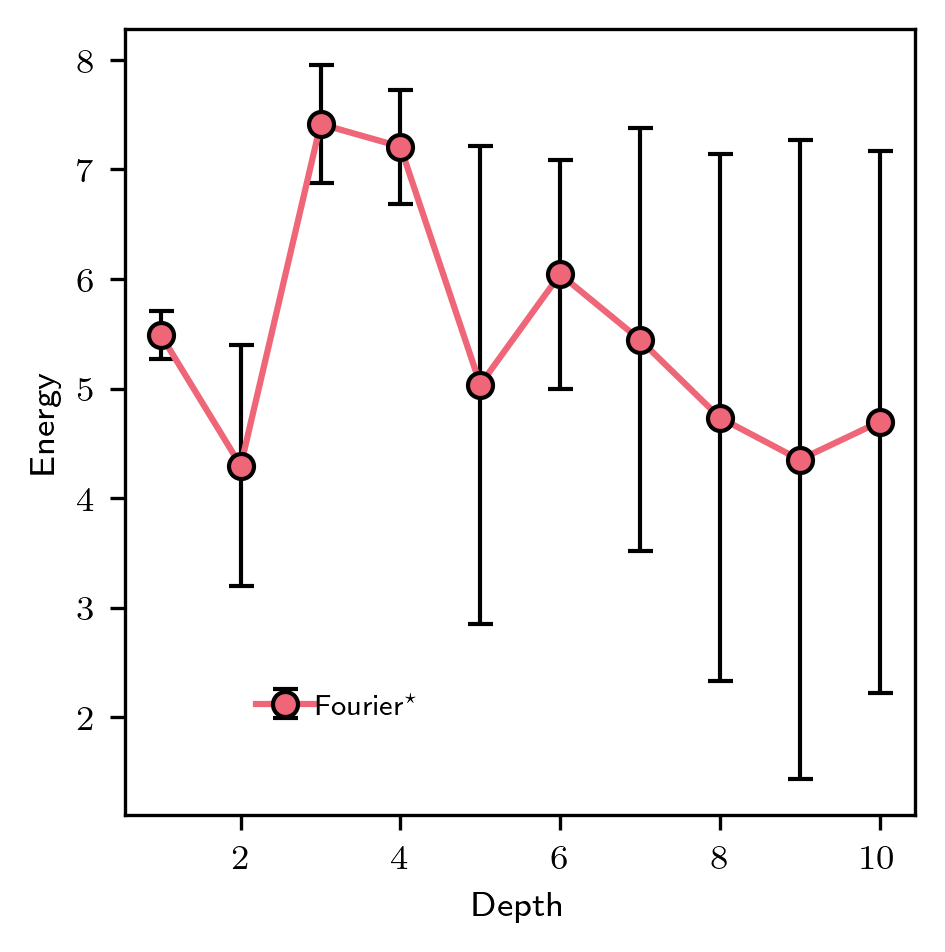

In [8]:
# ── Plot ─────────────────────────────────────────────────────────────────────

figure_styles.apply_rcparams()
fig, ax = plt.subplots(
    dpi=figure_styles.FIGURE_DPI,
    figsize=figure_styles.figsize(aspect_ratio=1.0),
)

for method_label in SV_METHOD_LABELS:
    rows = df[df["method_label"] == method_label]
    if rows.empty:
        continue
    stats = (
        rows.groupby("depth")["energy"]
        .agg(mean="mean", std="std")
        .reset_index()
        .sort_values("depth")
    )
    ax.errorbar(
        stats["depth"].to_numpy(),
        stats["mean"].to_numpy(),
        yerr=stats["std"].to_numpy(),
        label=figure_styles.format_method_label(method_label),
        **figure_styles.style_errorbar(method_label, "SV"),
    )

ax.set_xlabel("Depth")
ax.set_ylabel("Energy")
ax.legend(**figure_styles.method_legend_kwargs())

fig.savefig(OUTPUT_FILE, **figure_styles.savefig_kwargs())
fig.show()